# Static Networks - Training and evaluating neural networks

Once the static image stimulus $s$ is paired with the corresponding population response $\mathbf{r}$, it is time for us to train neural networks to predict the population resopnse from the static image, thereby approximating the true underlying function $\mathbf{r} = f(s)$.

Given that all information needed for training can be found inside a single HDF5 (corresponding to a single `InputResponse` entry), you don't actually have to use DataJoint to go about training a network on the neuronal data. However, there is a huge benefit in using DataJoint for neural network training as it allows you to keep track of all networks trained under any hyperparameter combinations and you can save the fully trained model in a manner tightly paired to the database so that you know exactly which dataset that the model was trained on.

The [`static-networks` repository](https://github.com/cajal/static-networks) provides a framework to train a network that fits the form of "core", "readout", "shifter" and "modulator" as was described in (Sinz et al, 2018) as well as in (Walker et al, 2018).

![network architecture](./architecture.png)

`static-networks` repository actually consists of multiple packages, among which are: `staticnet`, `staticnet_experiments` and `staticnet_analysis`.

In [55]:
import datajoint as dj
import torch
import numpy as np
import matplotlib.pyplot as plt

## `staticnet` package

`staticnet` package defines PyTorch modules that serve as the building blocks for the complete network, defining modules for "cores", "readouts", "shifters" and "modulators". This is reflected by the fact that `staticnet` have so-named subpackages.

In [17]:
from staticnet import cores, readouts, shifters, modulators

In [18]:
cores.Stacked2dCore??

Init signature:
cores.Stacked2dCore(
    input_channels,
    hidden_channels,
    input_kern,
    hidden_kern,
    layers=3,
    gamma_hidden=0,
    gamma_input=0.0,
    skip=0,
    final_nonlinearity=True,
    bias=False,
    skip_nonlin=False,
    momentum=0.1,
    pad_input=True,
    batch_norm=True,
    laplace_padding=0,
    laplace_weights_fn=None,
    **kwargs,
)
Docstring:     
Base class for all neural network modules.

Your models should also subclass this class.

Modules can also contain other Modules, allowing to nest them in
a tree structure. You can assign the submodules as regular attributes::

    import torch.nn as nn
    import torch.nn.functional as F

    class Model(nn.Module):
        def __init__(self):
            super(Model, self).__init__()
            self.conv1 = nn.Conv2d(1, 20, 5)
            self.conv2 = nn.Conv2d(20, 20, 5)

        def forward(self, x):
           x = F.relu(self.conv1(x))
           return F.relu(self.conv2(x))

Submodules assigned in

## `staticnet_experiments`

All tables used for building, training and evaluating neural networks are found under this package.

In [19]:
from staticnet_experiments import models

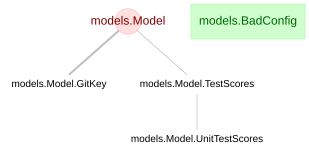

In [72]:
dj.ERD(models)

Ultimately, all network trainings occur inside `models.Model`

In [2]:
models.Model()

group_id index of group,net_hash unique identifier for configuration,seed random seed,val_corr validation correlation (single trial),model stored model
0,00035334cdc352a4ec6c0890972aa138,1009,0.255193,=BLOB=
0,00035334cdc352a4ec6c0890972aa138,1215,0.253165,=BLOB=
0,00035334cdc352a4ec6c0890972aa138,2606,0.249882,=BLOB=
0,00035334cdc352a4ec6c0890972aa138,99999,0.259384,=BLOB=
0,0011d8171d2c82d97ef3652e05b1f127,1009,0.269188,=BLOB=
0,0011d8171d2c82d97ef3652e05b1f127,2606,0.29432,=BLOB=
0,0011d8171d2c82d97ef3652e05b1f127,99999,0.29566,=BLOB=
0,001dea63893abe9404e5a7633071c60f,1009,0.29527,=BLOB=
0,001dea63893abe9404e5a7633071c60f,1215,0.296934,=BLOB=
0,001dea63893abe9404e5a7633071c60f,2606,0.299137,=BLOB=


Each entry corresponds to a single trained neural network, and you can easily grab the trained network using `load_network`.

In [4]:
model_keys = (models.Model & 'group_id = 21').fetch('KEY')

In [5]:
models.Model & model_keys[0]

group_id index of group,net_hash unique identifier for configuration,seed random seed,val_corr validation correlation (single trial),model stored model
21,0b2f5aa37929294595407bb16ff8f9c8,1009,0.263824,=BLOB=


In [60]:
net = models.Model().load_network(model_keys[0])

21-06-2019:08:13:07 INFO     configs.py           224:	 Ignoring input arguments: "schedule", "mod_hash", "train_hash", "train_type", "ro_hash", "net_hash", "max_epoch", "seed", "core_hash", "group_id", "shift_hash", "data_hash"when creating datasets
21-06-2019:08:13:07 INFO     configs.py           203:	 Loading None dataset with tier=train
21-06-2019:08:13:07 INFO     data_schemas.py      962:	 Fetching data for {'data_description': "V1 L2/3 on stimulus.Frame. normalize=True on all (except '')", 'mod_hash': 'a757e992ae449e3057ff1d512a51bd1e', 'train_hash': '2c25349fa0a81afbe907882e7b50a4da', 'stats_source': 'all', 'normalize': 1, 'ro_hash': 'a206f6da6a16ea14081062a1e2436b48', 'group_id': 21, 'seed': 1009, 'layer': 'L2/3', 'core_hash': 'e77f96c0b3ba781cbcf637d40e5fe396', 'normalize_per_image': 0, 'brain_area': 'V1', 'net_hash': '0b2f5aa37929294595407bb16ff8f9c8', 'shift_hash': '05c69a4aeaeea5e48fa8fc5e70181d67', 'data_hash': '7572eed73113c993e7d1b92f83e270b4'}
21-06-2019:08:13:07 INFO

/usr/local/lib/python3.5/dist-packages/h5py/_hl/dataset.py:313: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  "Use dataset[()] instead.", H5pyDeprecationWarning)


In [63]:
net

CorePlusReadout2d(
  (core): StackedLinearGaussianLaplaceCore(
    (_input_weights_regularizer): LaplaceL2(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(1, 32, kernel_size=(15, 15), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (layer1): Sequential(
        (conv): Conv2d(32, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
        (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (layer2): Sequential(
        (conv): Conv2d(64, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
        (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
  ) [StackedLinearGaussianLaplaceCore regularizers: gamma_hidden = 0.1|gamma_input = 100.0|skip = 3]
  
  (readout): SpatialTransformerPyramid2dReadout(
    (grou

You can feed in an arbitrary image through the network, provided that you give an image of valid size.

**CAUTION**: Here I'm using the fact that I know what the image size ought to be. In reality, you should figure this out from the dataset that was used to train the network.

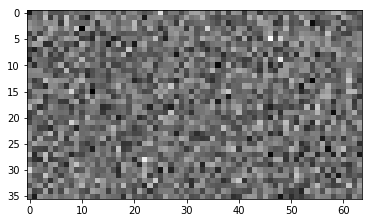

In [57]:
img = np.random.randn(1, 1, 36, 64)

# white noise image
plt.imshow(img.squeeze(), cmap='gray')

In [65]:
net.readout.keys()

odict_keys(['group021-20210-4-11-0'])

In [68]:
resp = net(torch.Tensor(img), readout_key='group021-20210-4-11-0')

In [71]:
resp.shape

torch.Size([1, 8127])

### More about the model

Let's take a closer look at the table:

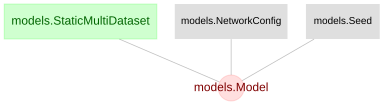

In [22]:
dj.ERD(models.Model) - 1

In [21]:
models.Model()

group_id index of group,net_hash unique identifier for configuration,seed random seed,val_corr validation correlation (single trial),model stored model
0,00035334cdc352a4ec6c0890972aa138,1009,0.255193,=BLOB=
0,00035334cdc352a4ec6c0890972aa138,1215,0.253165,=BLOB=
0,00035334cdc352a4ec6c0890972aa138,2606,0.249882,=BLOB=
0,00035334cdc352a4ec6c0890972aa138,99999,0.259384,=BLOB=
0,0011d8171d2c82d97ef3652e05b1f127,1009,0.269188,=BLOB=
0,0011d8171d2c82d97ef3652e05b1f127,2606,0.29432,=BLOB=
0,0011d8171d2c82d97ef3652e05b1f127,99999,0.29566,=BLOB=
0,001dea63893abe9404e5a7633071c60f,1009,0.29527,=BLOB=
0,001dea63893abe9404e5a7633071c60f,1215,0.296934,=BLOB=
0,001dea63893abe9404e5a7633071c60f,2606,0.299137,=BLOB=


You can see that each instance of a model is tied to a single `StaticMultiDataset`. `NetworkConfig` aggregrates all kinds of network variation including architecture hyperparameters as well as training configurations into a single hash. Seed corresponds to the seed used for the random initialization of the network. Calling `populate` on the `models.Model` will trigger the training of any remaining networks.

You can find the performance on the testset:

In [25]:
models.Model.TestScores() & model_keys[0]

group_id index of group,net_hash unique identifier for configuration,seed random seed,animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,spike_method spike inference method,preproc_id preprocessing ID,neurons number of neurons,pearson test correlation on single trial responses
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,8127,0.2484


And performance of unit on the testset:

In [26]:
models.Model.UnitTestScores() & model_keys[0]

group_id index of group,net_hash unique identifier for configuration,seed random seed,animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,spike_method spike inference method,preproc_id preprocessing ID,unit_id unique per scan & segmentation method,pearson test correlation on single trial responses
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,1,0.170469
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,3,0.0416346
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,4,0.0565228
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,5,0.168535
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,6,0.0708324
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,7,0.269573
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,8,0.109759
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,9,0.105057
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,10,0.291958
21,0b2f5aa37929294595407bb16ff8f9c8,1009,20210,4,11,1,6,5,0,11,0.163294


## Network configuration

The exact network configuration is entirely hidden under `NetworkConfig` which can be found under the `configs` subpackage of `staticnet_experiments`

In [27]:
from staticnet_experiments import configs

A `NetworkConfig` is really just a grouping of multiple subconfigurations:

In [42]:
configs.NetworkConfig.CorePlusReadout()

net_hash unique identifier for configuration,core_hash unique identifier for configuration,ro_hash unique identifier for configuration,shift_hash unique identifier for configuration,mod_hash unique identifier for configuration,train_hash unique identifier for configuration,data_hash unique identifier for configuration
0000777d3a17a81c352ab797b3fc733d,0ab3f20c01113b7e88bae9ab3d4b1f9c,e4cd67efe5a543b044cf8a74e440775e,05c69a4aeaeea5e48fa8fc5e70181d67,a757e992ae449e3057ff1d512a51bd1e,2c25349fa0a81afbe907882e7b50a4da,136a3d5b9513029651b57cce7f4cd0b7
00035334cdc352a4ec6c0890972aa138,2ab62d2074813aaa5cc39e58d5908c61,a206f6da6a16ea14081062a1e2436b48,05c69a4aeaeea5e48fa8fc5e70181d67,a757e992ae449e3057ff1d512a51bd1e,2c25349fa0a81afbe907882e7b50a4da,d507ca9ef5ffda1b1796d2ac8f98bb31
000783dc6a3b22ff02088c90bef4420c,ee871fb3600358a26593382658c1dd22,e4cd67efe5a543b044cf8a74e440775e,05c69a4aeaeea5e48fa8fc5e70181d67,a757e992ae449e3057ff1d512a51bd1e,421223be67c9d4c0d4dbd2fea5c51a74,d507ca9ef5ffda1b1796d2ac8f98bb31
000cc7efff7c3018c1a23a7756598ffb,61dab92e53b1f770e8009170e6e87d7c,5c0c374cb9a0edef3987e58620830df8,05c69a4aeaeea5e48fa8fc5e70181d67,a757e992ae449e3057ff1d512a51bd1e,46fb21d3f2634b82629c423a7e72fcf0,c4618dd0e4f2888569e022aca948a28e
000e9fac7f1eea433b2832919059f9ce,0d47a50a43cf183abce93ad9e8250415,e4cd67efe5a543b044cf8a74e440775e,355eb8cf32cc236c2d229ebbbb4c09af,a757e992ae449e3057ff1d512a51bd1e,421223be67c9d4c0d4dbd2fea5c51a74,2dbacc1e1c76781f72f67ef5b953ddbb
0010142509cbabb0f6a7f425b118cece,e3aed3896984322fb541a013e1f963ae,a206f6da6a16ea14081062a1e2436b48,05c69a4aeaeea5e48fa8fc5e70181d67,a757e992ae449e3057ff1d512a51bd1e,2c25349fa0a81afbe907882e7b50a4da,d50f571ae1b549e8585126b289f49b89
0011d8171d2c82d97ef3652e05b1f127,560acf8865e842e07203e84ec3a54e5c,c5cb097306f1cd9c491d898c66dde88e,05c69a4aeaeea5e48fa8fc5e70181d67,a757e992ae449e3057ff1d512a51bd1e,2c25349fa0a81afbe907882e7b50a4da,136a3d5b9513029651b57cce7f4cd0b7
001446ce49204b7f72d757145d91f4f9,6f1cb4289ee49e595487490c4e0b6b15,a206f6da6a16ea14081062a1e2436b48,355eb8cf32cc236c2d229ebbbb4c09af,a757e992ae449e3057ff1d512a51bd1e,46fb21d3f2634b82629c423a7e72fcf0,c18c87ccb6f2b296173514c39d478360
00163119cff7e86efd24c46bfacba94e,8fceddd89b5a5e9c441cd092fb2cf30d,e4cd67efe5a543b044cf8a74e440775e,05c69a4aeaeea5e48fa8fc5e70181d67,a757e992ae449e3057ff1d512a51bd1e,421223be67c9d4c0d4dbd2fea5c51a74,c4618dd0e4f2888569e022aca948a28e
0016c7cb9dc77017c99f588c5c892f98,10d64790088e540a0556ee885d5b6c15,a206f6da6a16ea14081062a1e2436b48,05c69a4aeaeea5e48fa8fc5e70181d67,a757e992ae449e3057ff1d512a51bd1e,2c25349fa0a81afbe907882e7b50a4da,c4618dd0e4f2888569e022aca948a28e


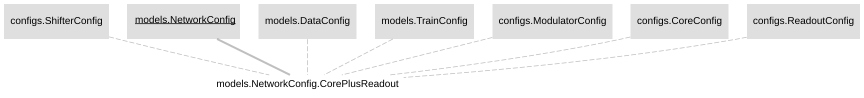

In [39]:
dj.ERD(configs.NetworkConfig) + (dj.ERD(configs.NetworkConfig.CorePlusReadout) - 1)

whereas each component config themselves are aggregation across numerous subtypes:

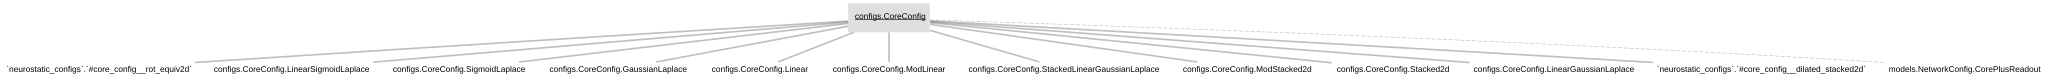

In [41]:
dj.ERD(configs.CoreConfig) + 1

In [43]:
configs.CoreConfig()

core_hash unique identifier for configuration,core_type type,core_ts automatic
004077f416f13dab32de139520aa629e,LinearGaussianLaplace,2018-10-30 18:57:10
004a23ebb07c6f1c9ad43cbbad9e6acf,LinearGaussianLaplace,2018-10-30 18:57:10
00cfe341ff27a14a23c4e341eb40f67f,GaussianLaplace,2018-10-25 10:32:28
02b4a074e3a7fa416459dc5684210893,ModStacked2d,2018-10-22 05:57:13
041853a713567cf1b61afa513a906181,GaussianLaplace,2018-10-25 10:32:28
0445c7f9ccc40fdd0d564fda363cbb01,GaussianLaplace,2018-10-25 10:32:26
0556ac949d5a0d34d8337efbf43efdd9,SigmoidLaplace,2018-10-24 05:21:09
06085df736e0866aff472f2f49151b36,SigmoidLaplace,2018-10-24 05:21:08
067d38505001effe616aff36978687fc,SigmoidLaplace,2018-10-24 05:21:09
0a36c4540ee500896d842567be2d889d,ModLinear,2018-10-22 05:57:13


## Finding out details about a trained network

Let's see how we can find out details about a particular trained network

In [44]:
target = model_keys[0]

In [45]:
models.Model & target

group_id index of group,net_hash unique identifier for configuration,seed random seed,val_corr validation correlation (single trial),model stored model
21,0b2f5aa37929294595407bb16ff8f9c8,1009,0.263824,=BLOB=


In [48]:
pairing = (models.Model & target) * configs.NetworkConfig.CorePlusReadout()

Inspect the core

In [49]:
configs.CoreConfig &  pairing

core_hash unique identifier for configuration,core_type type,core_ts automatic
e77f96c0b3ba781cbcf637d40e5fe396,StackedLinearGaussianLaplace,2018-12-12 08:27:36


In [50]:
configs.CoreConfig.StackedLinearGaussianLaplace &  pairing

core_hash unique identifier for configuration,hidden_channels hidden channels,input_kern kernel size at input convolutional layers,hidden_kern kernel size at hidden convolutional layers,layers layers,gamma_hidden regularization constant for hidden layers in CNN,gamma_input regularization constant for input convolutional layers,skip introduce skip connections if skip > 1,final_nonlinearity end last layer of core with nonlinearity,bias use bias or not,pad_input pad input layers,laplace_padding laplace padding,gauss_sigma sigma of Gaussian regularization weight,gauss_bias base line shift
e77f96c0b3ba781cbcf637d40e5fe396,32,15,7,3,0.1,100.0,3,1,0,0,1,0.5,0.0


Inspect the readout

In [51]:
configs.ReadoutConfig & pairing

ro_hash unique identifier for configuration,ro_type type,ro_ts automatic
a206f6da6a16ea14081062a1e2436b48,SpatialTransformerPyramid2d,2018-09-09 14:58:04


In [52]:
configs.ReadoutConfig.SpatialTransformerPyramid2d & pairing

ro_hash unique identifier for configuration,type regularization constant for features,gamma_features regularization constant for features,positive whether the features will be restricted to be positive,scale_n number of pooling steps in the readout,downsample whether to downsample lowpass representations
a206f6da6a16ea14081062a1e2436b48,gauss5x5,1.0,0,5,0


## Summary

In this notebook, we looked at two packages inside `static-networks` repository: `staticnet` and `staticnet_experiments`. Together, they define, train and evaluate neural networks on datasets as packaged and defined by `neuro_data.static_images`, specifically depending on the `StaticMultiDataset` table. Next, we'll take a look at one more package from the repository, `staticnet_analysis`, that houses code for generating and evaluating MEIs.